<a href="https://colab.research.google.com/github/DharankumarCS/fashion-mnist-atri/blob/main/notebooks/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


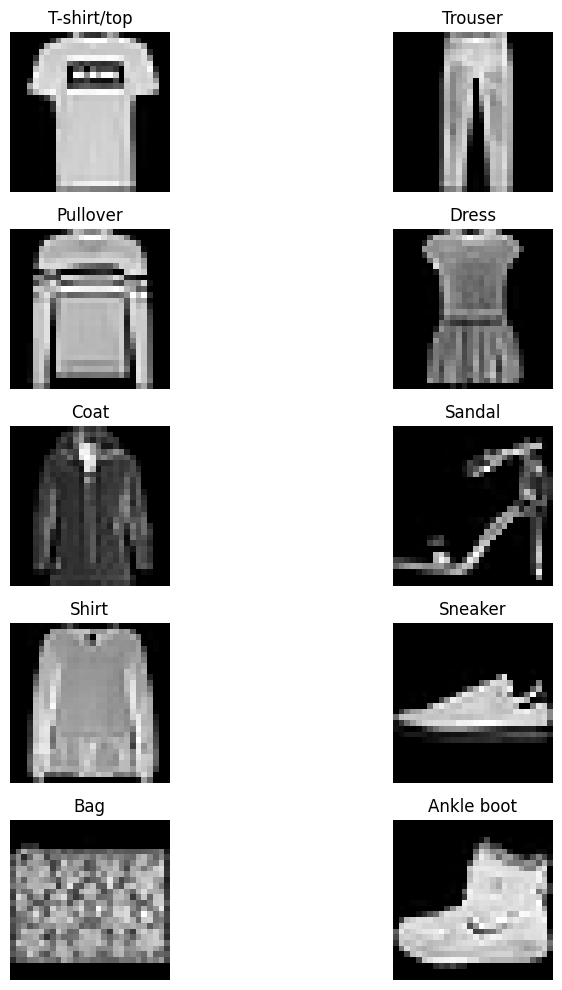

In [7]:
# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Fashion MNIST class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Plot one image from each class
plt.figure(figsize=(10,10))

for i in range(10):

    index = np.where(y_train == i)[0][0]

    plt.subplot(5,2,i+1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
#Question 1 completed

In [8]:
# Flatten 28x28 images into 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape:", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened testing shape: (10000, 784)


In [9]:
# One-hot encode labels

def one_hot_encode(labels, num_classes=10):

    one_hot = np.zeros((labels.size, num_classes))

    one_hot[np.arange(labels.size), labels] = 1

    return one_hot

y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)

print(y_train_encoded.shape)

(60000, 10)


In [10]:
def initialize_parameters(input_size, hidden_layers,
                          output_size, init_type="xavier"):
    parameters = {}
    layer_sizes = [input_size] + hidden_layers + [output_size]

    for i in range(1, len(layer_sizes)):
        n_in  = layer_sizes[i-1]
        n_out = layer_sizes[i]

        if init_type == "xavier":
            scale = np.sqrt(2.0 / (n_in + n_out))
        else:
            scale = 0.01

        parameters[f'W{i}'] = np.random.randn(n_out, n_in) * scale
        parameters[f'b{i}'] = np.zeros((n_out, 1))

    return parameters

In [14]:
def get_activation(Z, activation="relu"):
    if activation == "relu":
        return relu(Z)
    elif activation == "sigmoid":
        return sigmoid(Z)
    elif activation == "tanh":
        return tanh(Z)



In [16]:
def forward_propagation(X, parameters, activation="relu"):
    cache = {}
    A = X.T
    num_layers = len(parameters) // 2

    for i in range(1, num_layers):
        W = parameters[f'W{i}']
        b = parameters[f'b{i}']
        Z = np.dot(W, A) + b
        A = get_activation(Z, activation)  # flexible!
        cache[f'Z{i}'] = Z
        cache[f'A{i}'] = A

    # Output layer always softmax
    W = parameters[f'W{num_layers}']
    b = parameters[f'b{num_layers}']
    Z = np.dot(W, A) + b
    A = softmax(Z)
    cache[f'Z{num_layers}'] = Z
    cache[f'A{num_layers}'] = A

    return A, cache

In [23]:
import numpy as np

# activation functions
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def tanh(Z):
    return np.tanh(Z)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

# Test forward propagation
input_size = X_train_flat.shape[1]
output_size = y_train_encoded.shape[1]
hidden_layers = [128, 64] # Eg hidden layer sizes

parameters = initialize_parameters(input_size, hidden_layers, output_size)

output, cache = forward_propagation(X_train_flat[:5], parameters)

print("Output shape:", output.shape)
#Question 2 completed

Output shape: (10, 5)


In [25]:
# Cross entropy loss function

def compute_loss(Y, Y_hat):

    m = Y.shape[0]

    loss = -np.sum(Y.T * np.log(Y_hat + 1e-8)) / m

    return loss

In [26]:
# Test loss function

Y_sample = y_train_encoded[:5]

loss = compute_loss(Y_sample, output)

print("Loss:", loss)

Loss: 2.187190114358099


In [27]:
# ReLU derivative

def relu_derivative(Z):

    return (Z > 0).astype(float)

In [28]:
# Backpropagation

def backward_propagation(X, Y, parameters, cache):

    gradients = {}

    m = X.shape[0]

    num_layers = len(parameters) // 2

    A_final = cache[f'A{num_layers}']

    # Output layer gradient
    dZ = A_final - Y.T

    for i in reversed(range(1, num_layers + 1)):

        A_prev = X.T if i == 1 else cache[f'A{i-1}']

        gradients[f'dW{i}'] = (1 / m) * np.dot(dZ, A_prev.T)
        gradients[f'db{i}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

        if i > 1:

            W = parameters[f'W{i}']
            Z_prev = cache[f'Z{i-1}']

            dA_prev = np.dot(W.T, dZ)

            dZ = dA_prev * relu_derivative(Z_prev)

    return gradients

In [29]:
# Test backpropagation

gradients = backward_propagation(
    X_train_flat[:5],
    y_train_encoded[:5],
    parameters,
    cache
)

print(gradients.keys())

dict_keys(['dW3', 'db3', 'dW2', 'db2', 'dW1', 'db1'])


In [32]:
# Update parameters and SGD
def update_parameters(parameters, gradients, learning_rate):
    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):
        parameters[f'W{i}'] = parameters[f'W{i}'] - learning_rate * gradients[f'dW{i}']
        parameters[f'b{i}'] = parameters[f'b{i}'] - learning_rate * gradients[f'db{i}']

    return parameters

learning_rate = 0.01 # Define a learning rate

updated_parameters = update_parameters(parameters, gradients, learning_rate)

print("Parameters updated for W1 (first few values):\n", updated_parameters['W1'][:2, :2])

Parameters updated for W1 (first few values):
 [[ 0.12379596 -0.00719629]
 [ 0.01172517 -0.01668256]]


In [33]:
# Initialize velocity for Momentum

def initialize_velocity(parameters):

    velocity = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        velocity[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        velocity[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return velocity

In [34]:
# Momentum optimizer

def update_parameters_momentum(parameters, gradients,
                               velocity, learning_rate,
                               beta=0.9):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update velocity
        velocity[f'dW{i}'] = (
            beta * velocity[f'dW{i}']
            + (1 - beta) * gradients[f'dW{i}']
        )

        velocity[f'db{i}'] = (
            beta * velocity[f'db{i}']
            + (1 - beta) * gradients[f'db{i}']
        )

        # Update parameters
        parameters[f'W{i}'] -= learning_rate * velocity[f'dW{i}']

        parameters[f'b{i}'] -= learning_rate * velocity[f'db{i}']

    return parameters, velocity

In [35]:
# Test Momentum optimizer

velocity = initialize_velocity(parameters)

parameters, velocity = update_parameters_momentum(
    parameters,
    gradients,
    velocity,
    learning_rate=0.01
)

print("Momentum update completed")

Momentum update completed


In [36]:
# Nesterov Accelerated Gradient (NAG)

def update_parameters_nag(parameters, gradients,
                          velocity, learning_rate,
                          beta=0.9):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Store previous velocity
        v_prev_dW = velocity[f'dW{i}'].copy()
        v_prev_db = velocity[f'db{i}'].copy()

        # Update velocity
        velocity[f'dW{i}'] = (
            beta * velocity[f'dW{i}']
            + learning_rate * gradients[f'dW{i}']
        )

        velocity[f'db{i}'] = (
            beta * velocity[f'db{i}']
            + learning_rate * gradients[f'db{i}']
        )

        # NAG parameter update
        parameters[f'W{i}'] -= (
            -beta * v_prev_dW
            + (1 + beta) * velocity[f'dW{i}']
        )

        parameters[f'b{i}'] -= (
            -beta * v_prev_db
            + (1 + beta) * velocity[f'db{i}']
        )

    return parameters, velocity

In [37]:
# Test NAG optimizer

velocity = initialize_velocity(parameters)

parameters, velocity = update_parameters_nag(
    parameters,
    gradients,
    velocity,
    learning_rate=0.01
)

print("NAG update completed")

NAG update completed


In [38]:
# Initialize RMSProp cache

def initialize_rmsprop(parameters):

    cache = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        cache[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        cache[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return cache

In [39]:
# RMSProp optimizer

def update_parameters_rmsprop(parameters, gradients,
                              cache, learning_rate,
                              beta=0.9, epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update cache
        cache[f'dW{i}'] = (
            beta * cache[f'dW{i}']
            + (1 - beta) * (gradients[f'dW{i}'] ** 2)
        )

        cache[f'db{i}'] = (
            beta * cache[f'db{i}']
            + (1 - beta) * (gradients[f'db{i}'] ** 2)
        )

        # Update parameters
        parameters[f'W{i}'] -= (
            learning_rate
            * gradients[f'dW{i}']
            / (np.sqrt(cache[f'dW{i}']) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * gradients[f'db{i}']
            / (np.sqrt(cache[f'db{i}']) + epsilon)
        )

    return parameters, cache

In [40]:
# Test RMSProp optimizer

cache = initialize_rmsprop(parameters)

parameters, cache = update_parameters_rmsprop(
    parameters,
    gradients,
    cache,
    learning_rate=0.001
)

print("RMSProp update completed")

RMSProp update completed


In [41]:
# Initialize Adam variables

def initialize_adam(parameters):

    v = {}
    s = {}

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        v[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        v[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

        s[f'dW{i}'] = np.zeros_like(parameters[f'W{i}'])
        s[f'db{i}'] = np.zeros_like(parameters[f'b{i}'])

    return v, s

In [42]:
# Adam optimizer

def update_parameters_adam(parameters, gradients,
                           v, s, t,
                           learning_rate=0.001,
                           beta1=0.9,
                           beta2=0.999,
                           epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Momentum
        v[f'dW{i}'] = (
            beta1 * v[f'dW{i}']
            + (1 - beta1) * gradients[f'dW{i}']
        )

        v[f'db{i}'] = (
            beta1 * v[f'db{i}']
            + (1 - beta1) * gradients[f'db{i}']
        )

        # RMSProp
        s[f'dW{i}'] = (
            beta2 * s[f'dW{i}']
            + (1 - beta2) * (gradients[f'dW{i}'] ** 2)
        )

        s[f'db{i}'] = (
            beta2 * s[f'db{i}']
            + (1 - beta2) * (gradients[f'db{i}'] ** 2)
        )

        # Bias correction
        v_corrected_dW = v[f'dW{i}'] / (1 - beta1**t)
        v_corrected_db = v[f'db{i}'] / (1 - beta1**t)

        s_corrected_dW = s[f'dW{i}'] / (1 - beta2**t)
        s_corrected_db = s[f'db{i}'] / (1 - beta2**t)

        # Parameter update
        parameters[f'W{i}'] -= (
            learning_rate
            * v_corrected_dW
            / (np.sqrt(s_corrected_dW) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * v_corrected_db
            / (np.sqrt(s_corrected_db) + epsilon)
        )

    return parameters, v, s

In [43]:
# Test Adam optimizer

v, s = initialize_adam(parameters)

parameters, v, s = update_parameters_adam(
    parameters,
    gradients,
    v,
    s,
    t=1
)

print("Adam update completed")

Adam update completed


In [44]:
# Nadam optimizer

def update_parameters_nadam(parameters, gradients,
                            v, s, t,
                            learning_rate=0.001,
                            beta1=0.9,
                            beta2=0.999,
                            epsilon=1e-8):

    num_layers = len(parameters) // 2

    for i in range(1, num_layers + 1):

        # Update momentum
        v[f'dW{i}'] = (
            beta1 * v[f'dW{i}']
            + (1 - beta1) * gradients[f'dW{i}']
        )

        v[f'db{i}'] = (
            beta1 * v[f'db{i}']
            + (1 - beta1) * gradients[f'db{i}']
        )

        # Update RMSProp cache
        s[f'dW{i}'] = (
            beta2 * s[f'dW{i}']
            + (1 - beta2) * (gradients[f'dW{i}'] ** 2)
        )

        s[f'db{i}'] = (
            beta2 * s[f'db{i}']
            + (1 - beta2) * (gradients[f'db{i}'] ** 2)
        )

        # Bias correction
        v_corrected_dW = (
            beta1 * v[f'dW{i}']
            + ((1 - beta1) * gradients[f'dW{i}'])
        ) / (1 - beta1**t)

        v_corrected_db = (
            beta1 * v[f'db{i}']
            + ((1 - beta1) * gradients[f'db{i}'])
        ) / (1 - beta1**t)

        s_corrected_dW = s[f'dW{i}'] / (1 - beta2**t)
        s_corrected_db = s[f'db{i}'] / (1 - beta2**t)

        # Update parameters
        parameters[f'W{i}'] -= (
            learning_rate
            * v_corrected_dW
            / (np.sqrt(s_corrected_dW) + epsilon)
        )

        parameters[f'b{i}'] -= (
            learning_rate
            * v_corrected_db
            / (np.sqrt(s_corrected_db) + epsilon)
        )

    return parameters, v, s

In [45]:
# Test Nadam optimizer

v, s = initialize_adam(parameters)

parameters, v, s = update_parameters_nadam(
    parameters,
    gradients,
    v,
    s,
    t=1
)

print("Nadam update completed")
#question 3 completed

Nadam update completed


In [47]:
# Accuracy function

def compute_accuracy(Y_true, Y_pred):

    true_labels = np.argmax(Y_true, axis=1)
    predicted_labels = np.argmax(Y_pred.T, axis=1)

    accuracy = np.mean(true_labels == predicted_labels)

    return accuracy

In [48]:
# Training loop

def train_network(X_train, Y_train,
                  parameters,
                  epochs=10,
                  learning_rate=0.01):

    for epoch in range(epochs):

        # Forward propagation
        output, cache = forward_propagation(
            X_train,
            parameters,
            activation="relu"
        )

        # Loss
        loss = compute_loss(Y_train, output)

        # Backpropagation
        gradients = backward_propagation(
            X_train,
            Y_train,
            parameters,
            cache
        )

        # SGD update
        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        # Accuracy
        accuracy = compute_accuracy(Y_train, output)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

    return parameters

In [49]:
# Train the neural network

trained_parameters = train_network(
    X_train_flat[:1000],
    y_train_encoded[:1000],
    parameters,
    epochs=5,
    learning_rate=0.01
)

Epoch 1/5 | Loss: 3.6506 | Accuracy: 0.1080
Epoch 2/5 | Loss: 2.9473 | Accuracy: 0.1780
Epoch 3/5 | Loss: 2.5926 | Accuracy: 0.1930
Epoch 4/5 | Loss: 2.3866 | Accuracy: 0.1990
Epoch 5/5 | Loss: 2.2575 | Accuracy: 0.2030
